# Introducción al aprendizaje automatizado (O2026)

## Tutorial 4. Métodos No Supervisados - Análisis de Clústers

**Objetivo:**
Que se familiaricen con el segundo método no supervisado de: clústers 

### Repaso: Aprendizaje no supervisado
En gran parte del curso estudiamos modelos supervisados. Ahora veremos una herramienta no supervisada.

Cuando hablamos de **aprendizaje no supervisado** nos referimos a los casos en los que solo tenemos una cierta cantidad de _features_ o $X$, pero no contamos con una variable dependiente $Y$.

Por lo tanto, el objetivo no es predecir. El objetivo puede ser realizar un análisis explotatorio de los datos, ver las relaciones entre las $X$ y ver si encontramos subgrupos (clusters) en los datos.

No contar con la variable de respuesta Y implica que tampoco podemos chequear si lo que estamos haciendo funciona bien o mal.
Por ende, perdemos la posibilidad de métodos de validación cruzada.

### Métodos de Clustering: K-means

Clustering hace referencia a un conjunto de técnicas para encontrar subgrupos, o clusters, en los datos. Se busca partir a las observaciones en distintos grupos tal que las observaciones dentro de cada grupo sean similares entre sí y las observaciones en distintos grupos sean diferentes.

En esta clase veremos tres métodos de Clusters:
1. K-medias: para cuando nuestras variables en $X$ son *numéricas*
2. K-modas: para cuando tenemos variables *categorícas* en nuestras características en $X$ 
3. Cluster Jerárquico

### 1. K-medias (*k-means*)

En **K-medias** clustering buscamos partir las observaciones en un número de clusters previamente especificado. Se determina el K deseado y el algoritmo asigna cada observación a a uno de los K clusters (sin superposición) buscando minimizar la variación intra-cluster. Para definir la variación intra-cluster la forma más usual es usar la distancia euclideana.

El procedimiento consiste en:
1. Asignación inicial a los clusters. Asignar aleatoriamente un número de 1 a K a cada una de las observaciones. 
2. Iterar los siguientes pasos hasta que el cluster deja de modificarse:

a) Para cada uno de los K clusters, se computa el centroide. El centroide del k-ésimo cluster es un vector con las p medias de las características (_features_ o formalmente $\bar{X}_{k}$) de las observaciones en el cluster.

b) Reasignar a cada observación al cluster cuyo centroide es **más cercano** (en términos de la distancia euclideana al centroide).
  

Ejemplo: **Progreso de K-means clustering con K=3**

0. Observaciones
1. Cada observación se asigna aleatoriamente a un cluster.
2. Se computan los centroides de cada cluster (círculos más grandes). Al principio los centroides se superponen porque la asignación a los clusters fue elegida de forma aleatoria.
3. Cada observación se asigna al centroide más cercano.
4. Empieza una nueva iteración, se repite el paso 2, obteniendo nuevos centroides para cada clusters.
5. Resultados luego de 10 iteraciones.

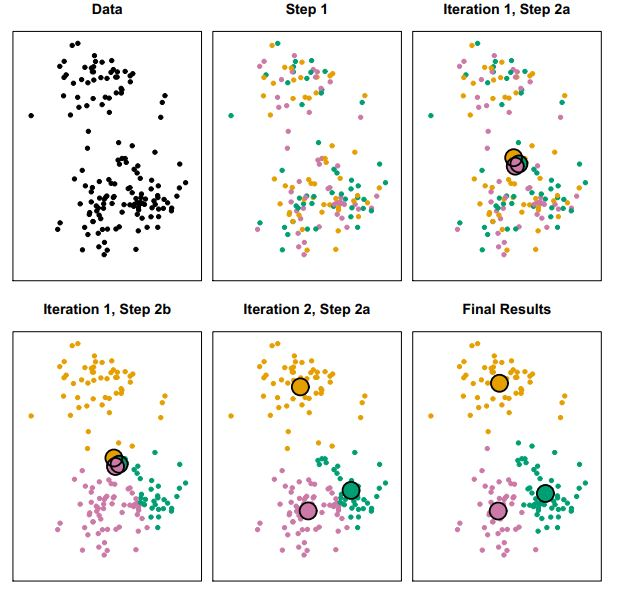

Usaremos el estimador [KMeans()](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) del módulo Cluster de Scikit Learn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering

Comencemos con un ejemplo simulado, en el que hay dos clusters en los datos: el primero, con 25 observaciones, tiene un desplazamiento de la media en relación a las 25 observaciones siguientes, que forman el segundo cluster.

In [4]:
np.random.seed(0)
X = np.random.standard_normal((50,2)) 
# Observaciones random de un distribución Normal estándar con media=0 y stdev=1
# 50 observaciones, 2 columnas
X[:25,0] += 3 #primeras 25 filas de la col 0 
X[:25,1] -= 4 #primeras 25 filas de la col 1
#el grupo esta centrado en (3,-4)
X

array([[ 4.76405235, -3.59984279],
       [ 3.97873798, -1.7591068 ],
       [ 4.86755799, -4.97727788],
       [ 3.95008842, -4.15135721],
       [ 2.89678115, -3.5894015 ],
       [ 3.14404357, -2.54572649],
       [ 3.76103773, -3.87832498],
       [ 3.44386323, -3.66632567],
       [ 4.49407907, -4.20515826],
       [ 3.3130677 , -4.85409574],
       [ 0.44701018, -3.3463814 ],
       [ 3.8644362 , -4.74216502],
       [ 5.26975462, -5.45436567],
       [ 3.04575852, -4.18718385],
       [ 4.53277921, -2.53064123],
       [ 3.15494743, -3.62183748],
       [ 2.11221425, -5.98079647],
       [ 2.65208785, -3.84365103],
       [ 4.23029068, -2.79762015],
       [ 2.61267318, -4.30230275],
       [ 1.95144703, -5.42001794],
       [ 1.29372981, -2.0492246 ],
       [ 2.49034782, -4.4380743 ],
       [ 1.74720464, -3.22250964],
       [ 1.38610215, -4.21274028],
       [-0.89546656,  0.3869025 ],
       [-0.51080514, -1.18063218],
       [-0.02818223,  0.42833187],
       [ 0.06651722,

Text(0, 0.5, '$X_2$')

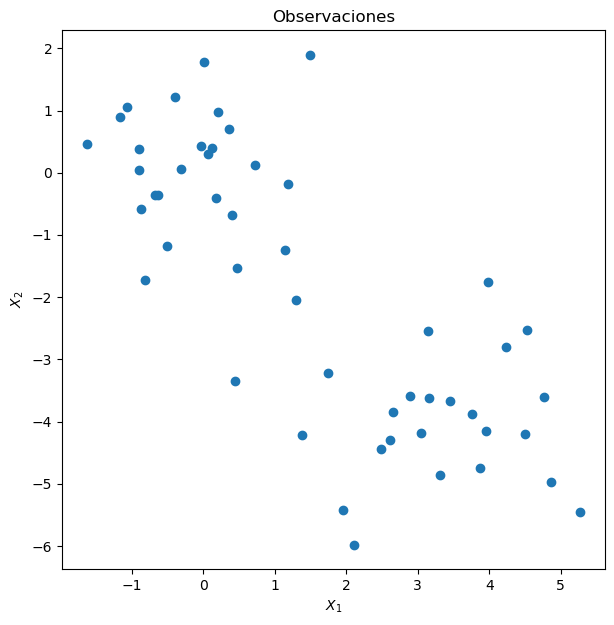

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(7,7))
ax.scatter(X[:,0], X[:,1]) 
ax.set_title("Observaciones")
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")

Ahora realizamos K-means clustering con K=2. Para más información ver:  [KMeans()](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) del módulo Cluster de Scikit Learn.

In [10]:
kmeans2 = KMeans(n_clusters=2, random_state=10, init="random", n_init=20).fit(X)
# n_clusters: número de clusters
# random_state: semilla (para poder reproducir los resultados)
# n_init: controla cuántas veces se ejecutará el algoritmo de K-means con diferentes semillas de centroides.
# init: lugar inicial del centroide
# Cada ejecución se realiza con una asignación aleatoria de centroides diferente.
# El resultado final es aquel con menor 'inertia' (suma de las distancias de cada punto a su centroide asignado, norma)
# Resumen:  
   # elegimos cómo poner los centroides (init),
   # probamos 20 veces (n_init), 
   # nos quedamos con la prueba que sea la mejor según la inercia, 
   # y con random_state nos aseguramos de que es reproducible el resultado.

Para ver a qué cluster fueron asignadas las 50 observaciones podemos usar el atributo <code>labels_</code> del objeto kmeans


In [7]:
kmeans2.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=int32)

Text(0, 0.5, '$X_2$')

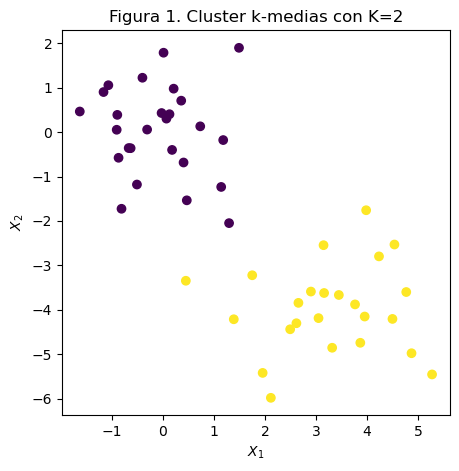

In [8]:
# Gráfico de las observaciones con las etiquetas correspondientes a cada cluster
fig, ax = plt.subplots(1, 1, figsize=(5,5))
ax.scatter(X[:,0], X[:,1], c=kmeans2.labels_)  #cmap
ax.set_title("Figura 1. Cluster k-medias con K=2")
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")


K-means clustering separó a las observaciones en dos grupos, las etiquetas son un resultado del procedimiento de clustering.
En este ejemplo es fácil gráficar porque solo tenemos dos dimensiones. Si hubiera más de dos variables podríamos realizar PCA y graficar los primeros dos vectores de componentes principales para representar a los clusters.

En este ejemplo sabíamos que eran dos clusters porque habíamos generado artificialmente los datos.
En otros casos reales, no sabemos de forma precisa el número de clusters ni si existen.
Podríamos haber hecho K-means Clustering con K=3 (**n_clusters**=3)


Text(0, 0.5, '$X_2$')

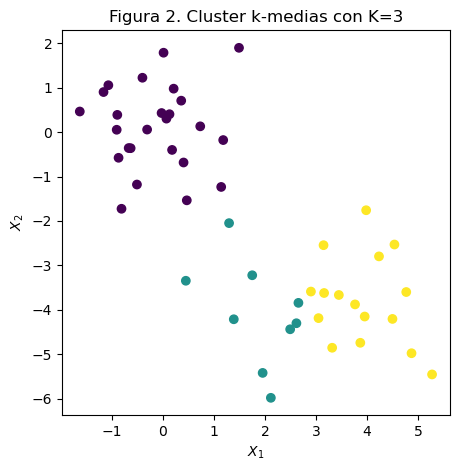

In [9]:
kmeans3 = KMeans(n_clusters=3, random_state=10, init="random", n_init=20).fit(X)

# Gráfico
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(X[:,0], X[:,1], c=kmeans3.labels_)
ax.set_title("Figura 2. Cluster k-medias con K=3")
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")

Notar que cuando K=3, el algoritmo parte los dos clusters iniciales

Otro parámetro de la función que definimos fue **n_init**. 
Este parámetro indica la cantidad de veces que se corre el algoritmo con distintas asignaciones iniciales. Este argumento en el ejemplo toma valor 20 (el valor por default es 10). Cuando n_init > 1, K-means clustering se realiza usando multiples asignaciones aleatorias iniciales y la función KMeans() reporta solo los mejores resultados.
Como los grupos obtenidos dependen de esa asignación aleatoria inicial, la recomendación es correr el algoritmo varias veces con distintas asignaciones iniciales (n_init de 20 o 50)

Vamos a comparar los resultados usando n_init=1, n_init=10, y n_init=20.

(También es importante setear una semilla usando el argumento random_state de KMeans(). Así, el las asignaciones iniciales a clusters pueden ser replicadas y el resultado será reproducible.)


In [12]:
kmeans3_i1 = KMeans(n_clusters=3, random_state=10, init="random", n_init=1).fit(X)
kmeans3_i10 = KMeans(n_clusters=3, random_state=10, init="random", n_init=10).fit(X)
kmeans3_i20 = KMeans(n_clusters=3, random_state=10, init="random", n_init=20).fit(X)
kmeans3_i1.inertia_, kmeans3_i10.inertia_, kmeans3_i20.inertia_

(77.18931183464503, 75.0350825910044, 75.0350825910044)

<code>kmeans.inertia_</code> es la **suma de los cuadrados total dentro de un cluster**. Inertia es una métrica que representa qué tan homogéneas son las observaciones dentro de un cluster. Nos interesa tener el menor valor posible, minimizar esta medida.

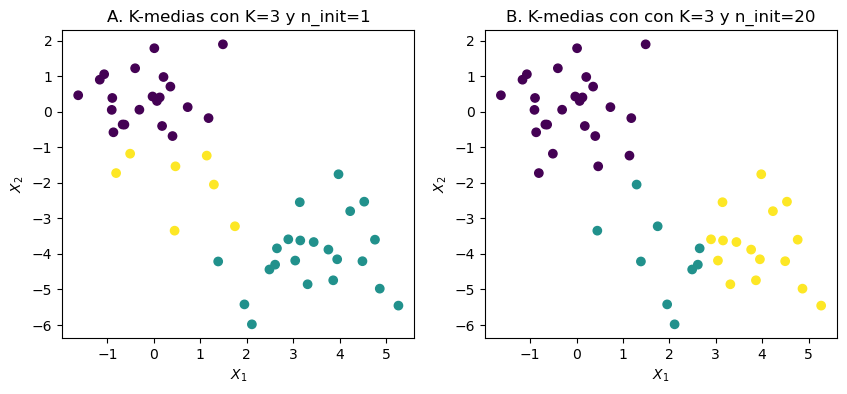

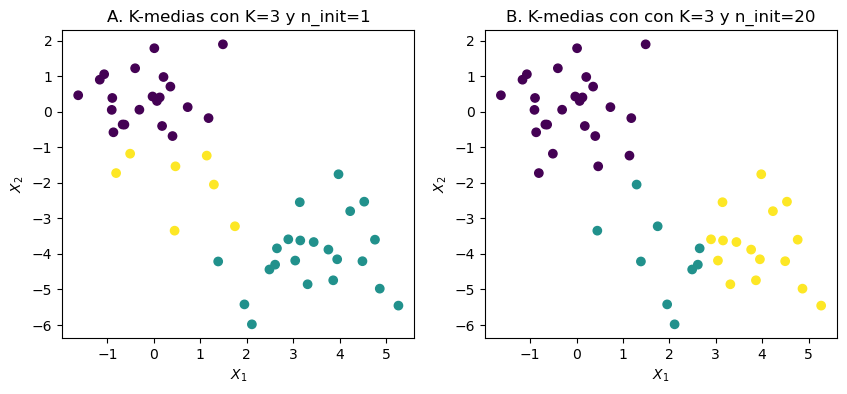

In [17]:
# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) 
ax = axes[0]
ax.scatter(X[:,0], X[:,1], c=kmeans3_i1.labels_)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_title("A. K-medias con K=3 y n_init=1")

ax = axes[1]
ax.scatter(X[:,0], X[:,1], c=kmeans3_i20.labels_)
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_title("B. K-medias con con K=3 y n_init=20")
fig


#### Método Elbown 
Como Inertia es una métrica que representa qué tan homogéneas son las observaciones dentro de un cluster. Podemos ver cómo cambia a media que tenemos un mayor número de clúster (`n_cluster`).

In [24]:
# Posibles valores del número de cluster
n_cluster_range = range(1,11)

# Objeto para guardad los valores de inertia
inertia_values = []

# Loop para probar distintos valores de cluser
for n_clusters in n_cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=10)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_) #agregams la inercia resultante al final de la lista.


In [23]:
inertia_values

[437.37238495606636,
 99.31537074091582,
 75.0350825910044,
 62.81025816892361,
 53.721376766714144,
 47.6183617181269,
 37.31761846100797,
 34.32931206165657,
 29.056318351266093,
 19.762972889038597]

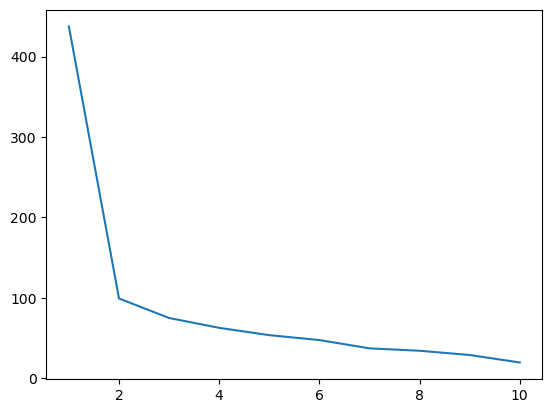

In [21]:
plt.plot(n_cluster_range, inertia_values)

<function matplotlib.pyplot.show(close=None, block=None)>

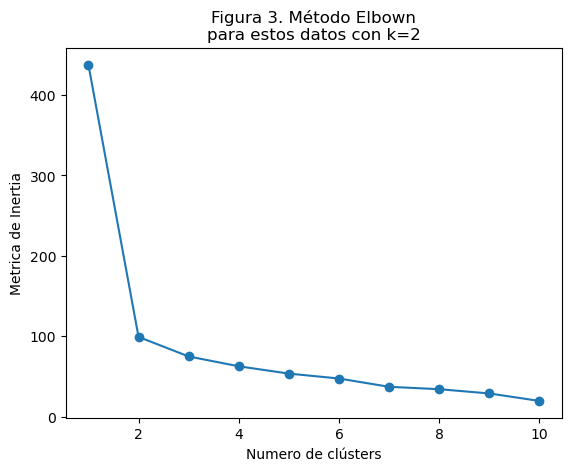

In [22]:
# Ahora graficamos como cambia inertia con los distintos clusters
plt.plot(n_cluster_range,inertia_values, marker='o')
plt.xlabel('Numero de clústers')
plt.ylabel('Metrica de Inertia')
plt.title('Figura 3. Método Elbown\npara estos datos con k=2')
plt.show

#### Ejercicio 1
Probar crear X con 3 grupos y replicar este gráfico. Cómo luce la caida de la Métrica en este segundo caso?

### 2. K-modas (k-mode)

El algoritmo **K-modas** es útil cuando trabajamos con datos **puramente categóricos** (ej.: color, marca, ciudad). En estos casos no tiene sentido calcular promedios, por lo que en lugar de usar medias como centroides utiliza **modas** (las categorías más frecuentes en cada cluster). La similitud se mide con la **distancia de Hamming** [(Torrent, 2019;p.3)](https://diposit.ub.edu/dspace/bitstream/2445/141500/1/TFG_LLOP_TORRENT_Neus%20.pdf), que cuenta cuántas categorías son diferentes entre un punto y un centroide. Por ejemplo, si dos observaciones son iguales en todos los atributos, la disimilitud es 0; mientras que si difieren en todas las caracteristicas entonces la disimilaridad será $n$. 
Así, una observación se asigna al cluster con el cual comparte más categorías (es decir, donde difiere en menos atributos). La interpretación de los resultados se hace leyendo los **perfiles típicos** de cada cluster: el vector de modas describe las características dominantes del grupo, y nos permite segmentar e identificar patrones comunes entre las observaciones.

Nota: Sección de la tutorial desarrollada en base a la siguiente tutorial en Kaggle con datos de bancos [link](https://www.kaggle.com/code/ashydv/bank-customer-clustering-k-modes-clustering/notebook)

In [35]:
# Primero, instalamos el paquete necesario de k-modas
!pip install kmodes

In [36]:
# Importamos los paquetes
from kmodes.kmodes import KModes
import pandas as pd
import seaborn as sns

In [28]:
# Creamos unos datos simples con 4 variables categóricas
df = pd.DataFrame({
    "Color":   ["Rojo","Azul","Verde","Rojo","Azul","Verde","Rojo","Azul","Rojo","Verde"],
    "Marca":   ["A","B","A","A","C","B","C","B","A","C"],
    "Talle":   ["S","M","L","M","S","M","L","S","M","L"],
    "Ciudad":  ["CABA","CABA","LaPlata","Córdoba","CABA","Rosario","Córdoba","Rosario","LaPlata","CABA"]
})

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Color   10 non-null     object
 1   Marca   10 non-null     object
 2   Talle   10 non-null     object
 3   Ciudad  10 non-null     object
dtypes: object(4)
memory usage: 452.0+ bytes


In [34]:
# convertimos el DataFrame en un array
X_cat = df.astype(str).values
X_cat

array([['Rojo', 'A', 'S', 'CABA'],
       ['Azul', 'B', 'M', 'CABA'],
       ['Verde', 'A', 'L', 'LaPlata'],
       ['Rojo', 'A', 'M', 'Córdoba'],
       ['Azul', 'C', 'S', 'CABA'],
       ['Verde', 'B', 'M', 'Rosario'],
       ['Rojo', 'C', 'L', 'Córdoba'],
       ['Azul', 'B', 'S', 'Rosario'],
       ['Rojo', 'A', 'M', 'LaPlata'],
       ['Verde', 'C', 'L', 'CABA']], dtype=object)

#### 2.1. Iniciación de *Huang*

Elige los centroides basándose en la frecuencia (probabilidad) de los valores categóricos en el dataset.

In [38]:
km = KModes(n_clusters=2, init="Huang", n_init=5, random_state=42, verbose=1)
labels = km.fit_predict(X_cat)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 2, cost: 18.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 1, cost: 17.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 2, cost: 17.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 17.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 3, cost: 17.0
Best run was number 2


Run: intento independiente del algoritmo seteado en n_int
Iteración: cantidad de iteraciones hasta converger. 
Costo: suma de diferencias categoricas entre cada punto y el centroide.

In [39]:
# le añadimos una columna a nuestro DataFrame a qué cluster pertenecen
df["cluster_predicho"] = labels

print("\nVisualizamos las Asignaciones de cluster k-modas:")
display(df)



Visualizamos las Asignaciones de cluster k-modas:


,Color,Marca,Talle,Ciudad,cluster_predicho
0,Rojo,A,S,CABA,0
1,Azul,B,M,CABA,0
2,Verde,A,L,LaPlata,1
3,Rojo,A,M,Córdoba,1
4,Azul,C,S,CABA,0
5,Verde,B,M,Rosario,0
6,Rojo,C,L,Córdoba,1
7,Azul,B,S,Rosario,0
8,Rojo,A,M,LaPlata,1
9,Verde,C,L,CABA,0


In [40]:
# Extraemos el centroide de ambos clusters
centroides = pd.DataFrame(km.cluster_centroids_, columns=df.columns[:-1])

print("\nVisualizamos los Centroides (modas) por cluster:")
display(centroides)


Visualizamos los Centroides (modas) por cluster:


,Color,Marca,Talle,Ciudad
0,Azul,B,S,CABA
1,Rojo,A,L,Córdoba


Podemos visualizar en graficos de barra, las observaciones por categoria de cada variable para ver estos clusters.

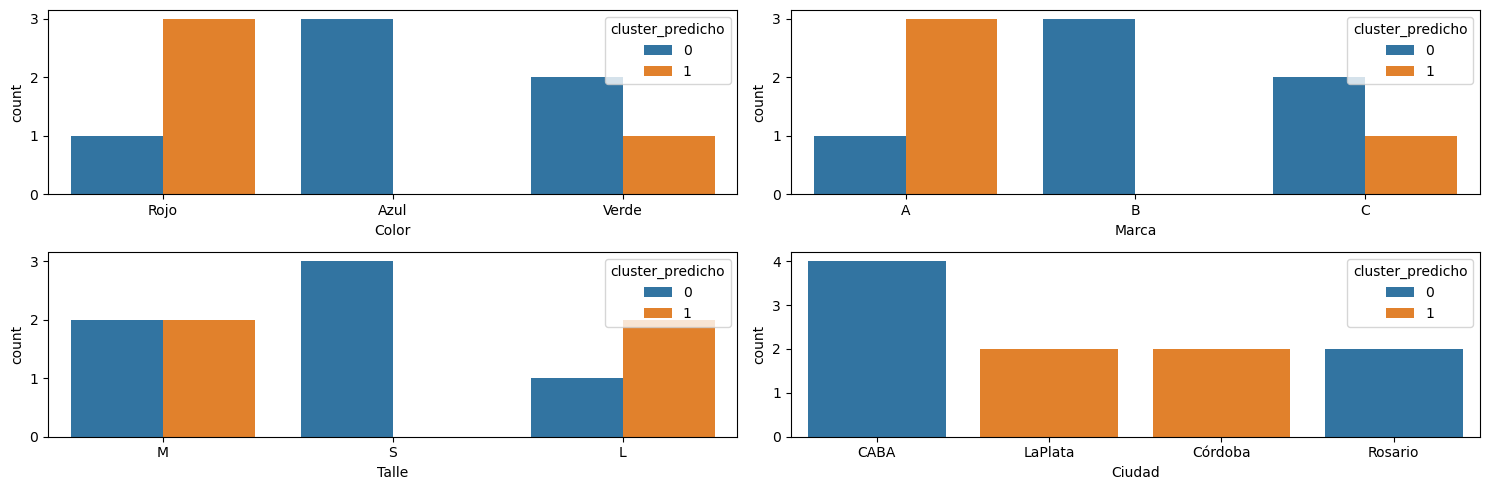

In [41]:
f, axs = plt.subplots(2,2,figsize = (15,5))
sns.countplot(x=df['Color'],order=df['Color'].value_counts().index,hue=df['cluster_predicho'],ax=axs[0,0])
sns.countplot(x=df['Marca'],order=df['Marca'].value_counts().index,hue=df['cluster_predicho'],ax=axs[0,1])
sns.countplot(x=df['Talle'],order=df['Talle'].value_counts().index,hue=df['cluster_predicho'],ax=axs[1,0])
sns.countplot(x=df['Ciudad'],order=df['Ciudad'].value_counts().index,hue=df['cluster_predicho'],ax=axs[1,1])

plt.tight_layout()
plt.show()

cluster 0: Azul, B, S, CABA

#### 2.2 Iniciación de *Cao*

Elige los centroides iniciales buscando que sean lo más diferentes entre sí posible. Selecciona puntos que maximicen la diversidad, para que los clusters arranquen bien separados.

In [44]:
km = KModes(n_clusters=2, init="Cao", random_state=42, verbose=1)
labels = km.fit_predict(X_cat)

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 17.0


In [45]:
# le añadimos una columna a nuestro DataFrame a qué cluster pertenecen con esta segunda iniciacion
df["cluster_predicho_cao"] = labels

print("\nVisualizamos las Asignaciones de cluster k-modas por tipo de iniciación:")
display(df)


Visualizamos las Asignaciones de cluster k-modas por tipo de iniciación:


,Color,Marca,Talle,Ciudad,cluster_predicho,cluster_predicho_cao
0,Rojo,A,S,CABA,0,0
1,Azul,B,M,CABA,0,1
2,Verde,A,L,LaPlata,1,0
3,Rojo,A,M,Córdoba,1,0
4,Azul,C,S,CABA,0,0
5,Verde,B,M,Rosario,0,1
6,Rojo,C,L,Córdoba,1,0
7,Azul,B,S,Rosario,0,1
8,Rojo,A,M,LaPlata,1,0
9,Verde,C,L,CABA,0,0


In [48]:
# Extraemos el centroide de ambos clusters
centroides2 = pd.DataFrame(km.cluster_centroids_, columns=df.columns[:4])

print(centroides==centroides2)

print("\nVisualizamos los Centroides (modas) por cluster con Cao:")
display(centroides2)
display(centroides) #de Huang

   Color  Marca  Talle  Ciudad
0  False  False  False    True
1  False  False  False   False

Visualizamos los Centroides (modas) por cluster con Cao:


,Color,Marca,Talle,Ciudad
0,Rojo,A,L,CABA
1,Azul,B,M,Rosario


,Color,Marca,Talle,Ciudad
0,Azul,B,S,CABA
1,Rojo,A,L,Córdoba


#### Ejercicio 2
Visualizar y comparar las 4 variables y sus caracteristicas con los dos metodos de iniciación.

### 3. Clúster jerárquico

En el caso de Clustering jerárquico, a diferencia de K-medias, **no es necesario especificar previamente el número de clusters**. Obtendremos una representación visual de las observaciones a partir de un **dendrograma** (arbol) que permite ver los subgrupos obtenidos para cada número posible de clusters (de 1 a n).

La forma más común de clustering jerárquico es _bottom-up_ o _agglomerative clustering_. Hace referencia a que el dendrograma se construye de abajo hacia arriba, comenzando por las hojas.

Usaremos [linkage()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage) y [dendrogram()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html) de Scipy.
También podríamos usar [AgglomerativeClustering()](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) de Scikit Learn (módulo Cluster).

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering #aglomerativo
from sklearn.datasets import load_iris

##### Ejemplo 1

In [52]:
# Creamos datos
x1 = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
x2 = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

data = list(zip(x1, x2)) # conjunto de datos bidimensional 
data
# Tuplas con un par de observaciones cada una 
# El 1° valor en la tupla es una observación de la lista x1 y el 2°, uno de la lista x2. 

[(4, 21),
 (5, 19),
 (10, 24),
 (4, 17),
 (3, 16),
 (11, 25),
 (14, 24),
 (6, 22),
 (10, 21),
 (12, 21)]

Text(0, 0.5, '$X_2$')

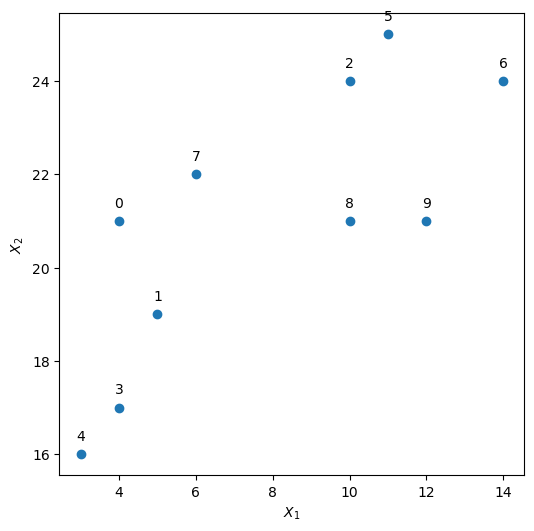

In [53]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(x1, x2)
for i, txt in enumerate(range(len(x1))):
    ax.annotate(txt, (x1[i], x2[i]), textcoords="offset points", xytext=(0,10), ha='center')
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')

In [56]:
from sklearn.preprocessing import StandardScaler

In [57]:
data_std = StandardScaler().fit_transform(data)
data_std

array([[-1.04643796,  0.        ],
       [-0.77812053, -0.70710678],
       [ 0.56346659,  1.06066017],
       [-1.04643796, -1.41421356],
       [-1.31475538, -1.76776695],
       [ 0.83178402,  1.41421356],
       [ 1.63673629,  1.06066017],
       [-0.50980311,  0.35355339],
       [ 0.56346659,  0.        ],
       [ 1.10010144,  0.        ]])

Ahora usamos linkage() de SciPy para realizar un agrupamiento jerárquico

- **Completa**:
Disimilitud máxima entre conglomerados. Calcula todas las disimilitudes por pares entre las observaciones del cluster A y las del cluster B, y registra la mayor de estas disimilitudes.
- **Simple (single)**:
Disimilitud mínima entre conglomerados. Calcula todas las disimilitudes por pares entre las observaciones del cluster A y las del cluster B, y registra la menor de estas disimilitudes. El link simple puede resultar en conglomerados extensos y rezagados, en los que las observaciones individuales se fusionan una a una.
- **Promedio**:
Disimilitud media entre conglomerados. Calcula todas las disimilitudes por pares entre las observaciones del cluster A y las del cluster B, y registra el promedio de estas disimilitudes.
- **Centroide**:
Diferencia entre el centroide del grupo A (un vector medio de longitud p) y el centroide del grupo B. La vinculación de centroides puede dar lugar a inversiones indeseables.

Fuente: para mas información pueden seguir esta tutorial [Ilustración de Cluster Jerárquico](https://dataaspirant.com/hierarchical-clustering-algorithm/)

Text(0, 0.5, 'Disimilitud')

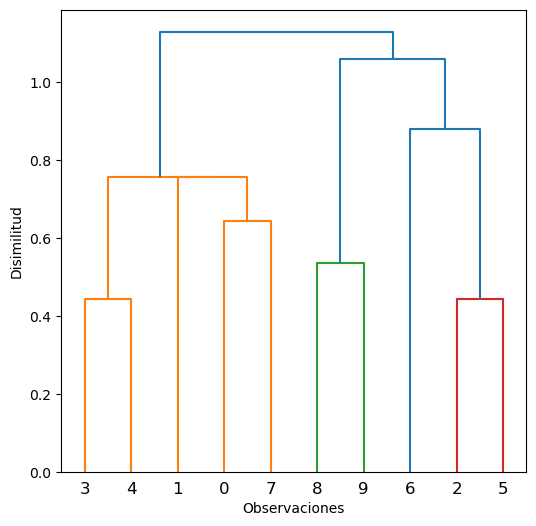

In [60]:
linkage_data = linkage(data_std, metric='euclidean')
# Algunos parámetros que están determinados por default:
# metric='euclidean', method='simple'

# Graficamos
fig, ax = plt.subplots(figsize=(6,6))
dendrogram(linkage_data)
ax.set_xlabel("Observaciones")
ax.set_ylabel("Disimilitud")


Text(0.5, 1.0, 'Dendrograma')

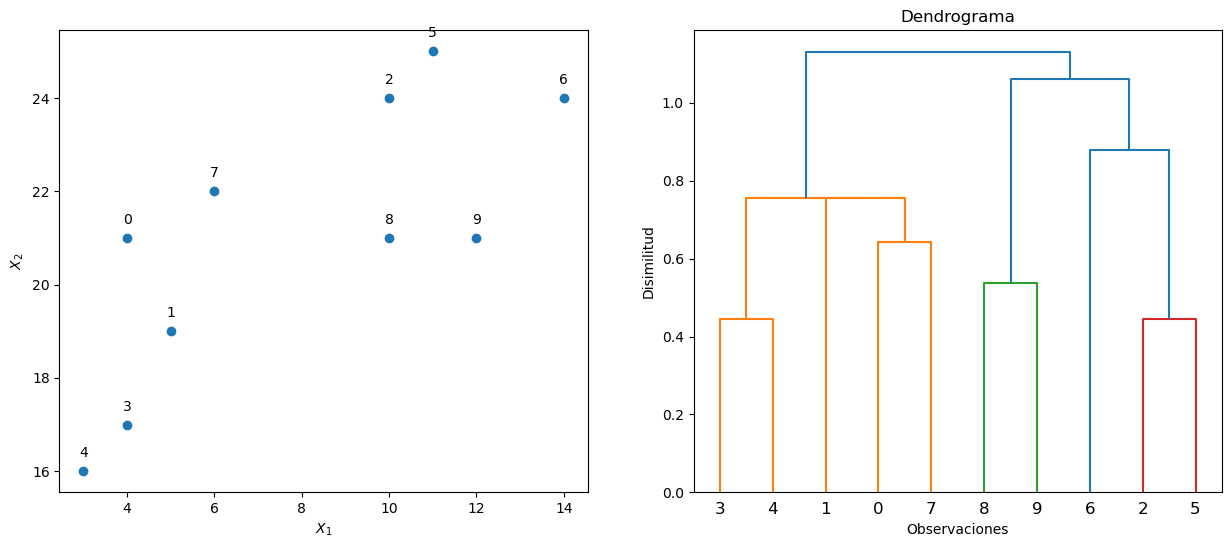

In [63]:
# Visualizamos las caracteristicas y el dendograma
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # 2 subplots uno al lado del otro
ax = axes[0]
ax.scatter(x1, x2)
for i, txt in enumerate(range(len(x1))):
    ax.annotate(txt, (x1[i], x2[i]), textcoords="offset points", xytext=(0,10), ha='center')
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')

ax = axes[1]
dendrogram(linkage_data)
ax.set_xlabel("Observaciones")
ax.set_ylabel("Disimilitud")
ax.set_title("Dendrograma")


Si  hacemos un corte horizontal en el dendograma podemos controlar cuántos clusters quedan.

[0 0 1 0 0 1 2 0 3 3]


/var/folders/wy/42flyl6d5wl9m3vp2mhsmm6w0000gn/T/ipykernel_11861/885959083.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


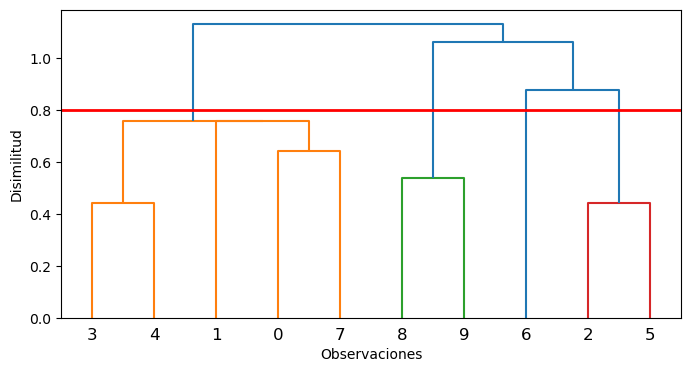

In [64]:
from scipy.cluster.hierarchy import cut_tree

# Para ver las etiquetas de clusters
# Si cortamos donde la altura es 0.8
labels_cut08 = cut_tree(linkage_data, height=0.8).reshape(-1)
print(labels_cut08)

fig, ax = plt.subplots(figsize=(8,4))
dendrogram(linkage_data)
ax.set_xlabel("Observaciones")
ax.set_ylabel("Disimilitud")
ax.axhline(0.8, c='red', linewidth=2) # línea horizontal en 4
fig.show()


In [65]:
# Si queremos 3 clusters
labels_clust3 = cut_tree(linkage_data, n_clusters=3).reshape(-1)
print(labels_clust3)

[0 0 1 0 0 1 1 0 2 2]


##### Ejemplo 2

Datos del dataset Iris, de Scikit-learn.

Features:
- Sepal length (in cm)
- Sepal width (in cm)
- Petal length (in cm)
- Petal width (in cm)

Target variable: the species of iris plant, which can take one of three possible values:
- Setosa
- Versicolor
- Virginica

In [ ]:
# Ejemplo 2
# Datos de Iris (3 tipos de flores)
iris = load_iris()

# Features
feature_names = iris.feature_names
print("Feature names:", feature_names)

# Target variable
target_names = iris.target_names
print("Target names:", target_names)
y = iris.target

X = iris.data
print("Dimension X:", X.shape)
print(X, y)

In [ ]:
# Estandarizamos nuestra matriz X
X_std = StandardScaler().fit_transform(X)

linkage_data = linkage(X_std, metric='euclidean', method='complete')

In [ ]:
# Visualizamos el dendograma
fig, ax = plt.subplots(figsize=(8,4))
dendrogram(linkage_data)
ax.set_xlabel("Observaciones")
ax.set_ylabel("Disimilitud")
fig.show()

In [ ]:
# Visualizamos un dendograma truncado cuando hay muchas observaciones:
fig, ax = plt.subplots(figsize=(8,4))
dendrogram(linkage_data, truncate_mode="level", p=3)
ax.set_xlabel("Observaciones")
ax.set_ylabel("Disimilitud")
fig.show()

In [ ]:
from scipy.cluster.hierarchy import cut_tree

# Para ver las etiquetas de clusters
# Si cortamos donde la altura es 4
labels_cut4 = cut_tree(linkage_data , height=4).reshape(-1)
print(labels_cut4)

fig, ax = plt.subplots(figsize=(8,4))
dendrogram(linkage_data)
ax.set_xlabel("Observaciones")
ax.set_ylabel("Disimilitud")
ax.axhline(4, c='red', linewidth=2) # línea horizontal en 4
fig.show()


In [ ]:
# Si queremos 3 clusters
labels_clust3 = cut_tree(linkage_data, n_clusters=3).reshape(-1)
print(labels_clust3)

pd.crosstab(pd.Series(labels_clust3, name='HClust'), pd.Series(y, name='Target'))

Mismo ejemplo usando Agglomerative Clustering de Scikitlearn

In [ ]:
ac = AgglomerativeClustering(n_clusters=3, # chose 3 since we know the iris dataset has three different species
                             linkage='complete')
ac_labels = ac.fit_predict(X_std)
print(f'Cluster labels: {ac_labels}')
pd.crosstab(pd.Series(ac_labels, name='Agglomerative Clustering'), pd.Series(y, name='Target'))

In [ ]:
# Comprobamos que aunque los nombres de las etiquetas cambian, las observaciones quedan clasificadas en los mismos clusters
pd.crosstab(pd.Series(labels_clust3, name='HClust'),pd.Series(ac_labels, name='Agglomerative Clustering'))

#### Ejercicio 3
1) Chequear las caracterísicas de los clusters usando la funcion AgglomerativeClustering y comparar con los 3 cluster de la función dendrogram()
2) Probar con 3 cluster y distintos linkages. Difieren mucho las carcateristicas promedios de los 4 tipos de linkage?